# Gradient descent

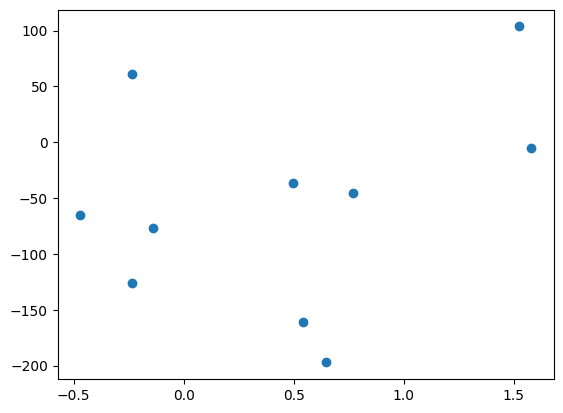

In [1]:
## start with smaller data set 
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt 

## making a dataset 
X,y =make_regression(n_samples =10,n_features =1,n_targets=1,noise =80,random_state=42)

## plot the X,y
plt.scatter(X,y)

In [2]:
## apply mean square method 
from sklearn.linear_model import LinearRegression
model =LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
print(model.intercept_)## this is value of b
print(model.coef_)# this is value of m(slope)

-72.31206498703408
[38.90319724]


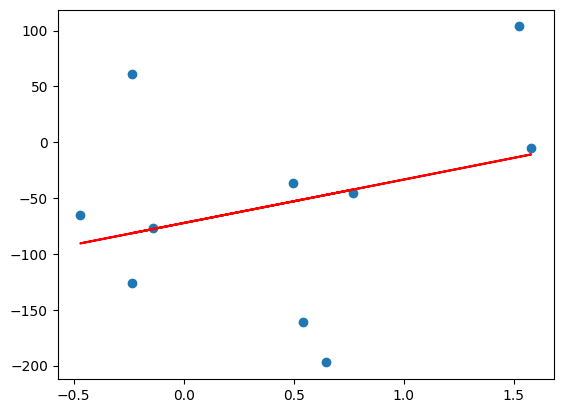

In [6]:
# now plot our best fit line
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')
plt.show()

In [21]:
## now we are going to apply gradient desecent to get this bestfit line
## y = mX+b
# slope(m) is const =38.90319724
# our aim is to get value of b = -72.31206498703408

# assume start value of b=100
y_pred = ((38.90)*X+100).ravel()# array ko flat kar dega
#y_pred = ((38.90)*X + 100).reshape(-1) ye bhi use kar skte 

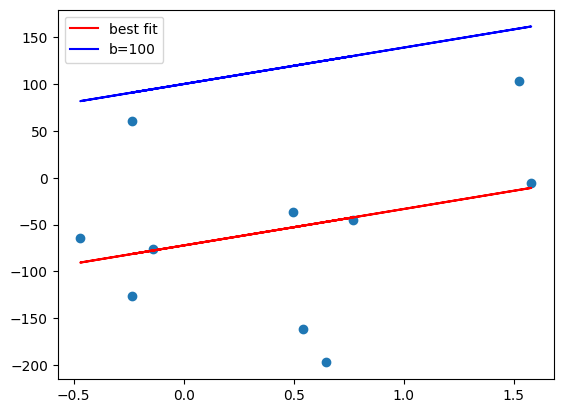

In [22]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='best fit')
plt.plot(X,y_pred,color='blue',label='b=100')
plt.legend()
plt.show()

In [40]:
## calculate the cost function 
m=38.90
b=100
loss =-2*np.sum(y - m*X.ravel()-b)
loss

np.float64(3446.2126485454705)

In [41]:
## now take learning rate lr=0.01
lr =0.01
step_size=loss*lr
step_size

np.float64(34.462126485454704)

In [42]:
#  calculate the new value of b 
b=b-step_size
b

np.float64(65.5378735145453)

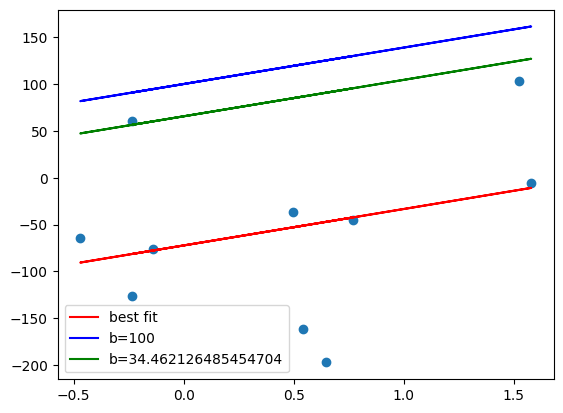

In [43]:
## take new value of b
y_pred1 = ((38.90)*X +b).ravel()
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='best fit')
plt.plot(X,y_pred,color='blue',label='b=100')
plt.plot(X,y_pred1,color='green',label='b=34.462126485454704')
plt.legend()
plt.show()

In [48]:
## lets do it again(Iteration 2)
# calculate loss
loss =-2 *np.sum(y - m*X.ravel()-b)
print('loss:',loss)
# calculate step_size
step_size=loss*lr
print('step_size :',step_size)
# calculate the new value of b
b = b -step_size
b

loss: 1764.460876055281
step_size : 17.64460876055281


np.float64(-1.732197385062289)

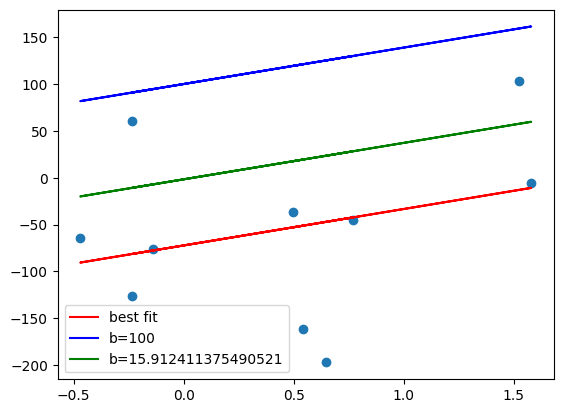

In [49]:
# plot karo

y_pred2 = ((38.90)*X +b).ravel()

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='best fit')
plt.plot(X,y_pred,color='blue',label='b=100')
plt.plot(X,y_pred2,color='green',label='b=15.912411375490521')
plt.legend()
plt.show()

In [50]:
## now iteration 3

# loss
loss = -2*np.sum(y - m*X.ravel() -b)
# step_size
step_size = loss*lr
# new b
b = b-step_size
b

np.float64(-15.847884393504536)

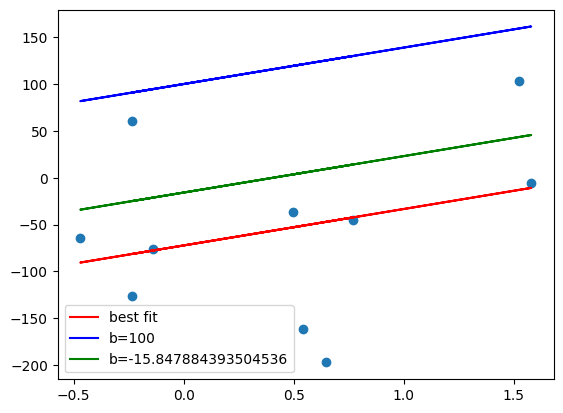

In [51]:
# plot for iteration 3
y_pred3 = ((38.90)*X +b).ravel()

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='best fit')
plt.plot(X,y_pred,color='blue',label='b=100')
plt.plot(X,y_pred3,color='green',label='b=-15.847884393504536')
plt.legend()
plt.show()

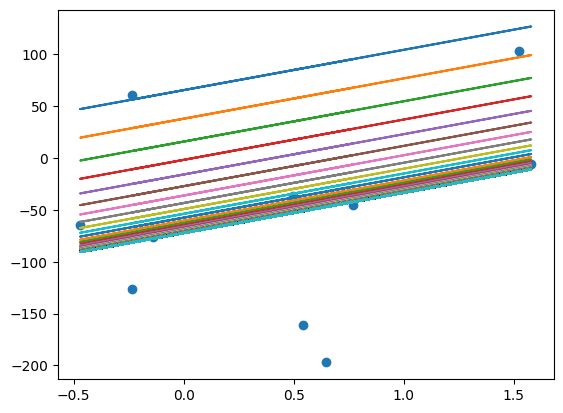

In [56]:
## apply loop for doing iteration
b=100
m=38.90
lr=0.01

epochs =10000

for i in range(epochs):
    loss = -2 *np.sum(y - m*X.ravel() -b)
    step_size =loss*lr
    b = b- step_size

    # equation
    y_pred =(m*X+b).ravel()
    plt.plot(X,y_pred)
plt.scatter(X,y)    

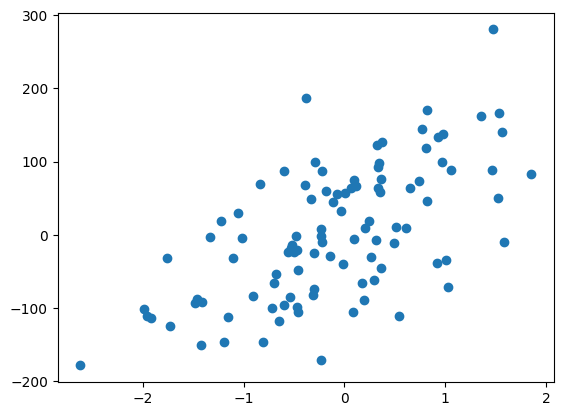

In [53]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt 

## making a dataset 
X,y =make_regression(n_samples =100,n_features =1,n_targets=1,noise =80,random_state=42)

## plot the X,y
plt.scatter(X,y)

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [55]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


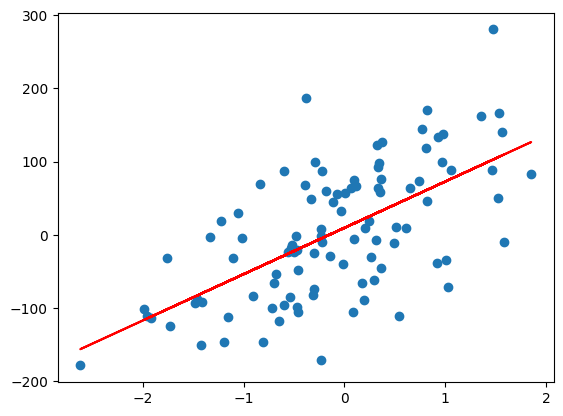

In [56]:
## plot our model visually
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')

In [57]:
model.coef_

array([63.30965773])

In [58]:
model.intercept_

np.float64(9.320922564215785)

In [59]:
m=63.30

In [60]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m =m
        self.b =0
        self.lr=learning_rate
        self.epochs =epochs

    def fit(self,X,y):
        # calculate the b using Gradient descent
        for i in range(self.epochs):
            loss =-2 * np.sum(y - self.m*X.ravel() -self.b)
            step_size = self.lr * loss
            self.b=self.b-step_size

            print(loss,self.b)
        print(self.b)    

In [61]:
# create a object of class
gd  = GDRegressor(0.001,250)
gd.fit(X,y)

-1863.9839284369828 1.8639839284369828
-1491.1871427495869 3.35517107118657
-1192.9497141996692 4.548120785386239
-954.3597713597361 5.502480556745975
-763.4878170877878 6.265968373833763
-610.7902536702308 6.876758627503994
-488.6322029361845 7.3653908304401785
-390.90576234894775 7.756296592789126
-312.72460987915804 8.069021202668285
-250.17968790332642 8.319200890571611
-200.14375032266116 8.519344640894273
-160.1150002581285 8.679459641152402
-128.0920002065027 8.807551641358904
-102.47360016520264 8.910025241524107
-81.97888013216166 8.992004121656269
-65.58310410572986 9.057587225762
-52.46648328458306 9.110053709046582
-41.97318662766685 9.152026895674249
-33.57854930213321 9.185605444976382
-26.86283944170728 9.212468284418089
-21.490271553365318 9.233958555971453
-17.192217242692607 9.251150773214146
-13.753773794153716 9.2649045470083
-11.003019035323575 9.275907566043623
-8.802415228258297 9.284709981271881
-7.0419321826074395 9.291751913454489
-5.633545746085645 9.29738545

upto this we are calculating the value of b when m is constant 
the function is only depend of b 
now we are going to see when function is depend on both the parameter m,b

value of b : 9.320922564215785
value of m : [63.30965773]
0.2649130147091289


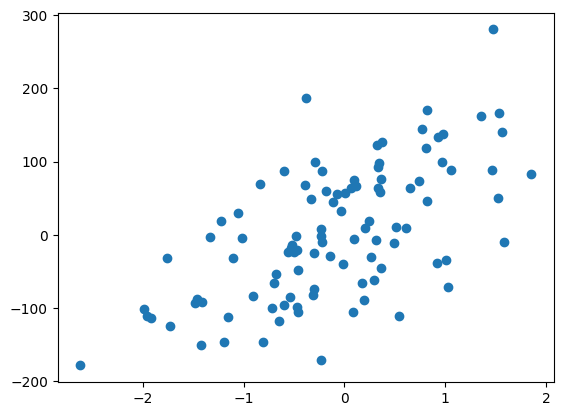

In [62]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import cross_val_score

## making a dataset 
X,y =make_regression(n_samples =100,n_features =1,n_targets=1,noise =80,random_state=42)

## plot the X,y
plt.scatter(X,y)

# train your model
from sklearn.linear_model import LinearRegression
model =LinearRegression()
model.fit(X,y)

# getting value of slope and intercept
print("value of b :",model.intercept_)
print("value of m :",model.coef_)

## getting a cross_val_score:cross_val_score function is a tool used to evaluate 
#how well a machine learning model generalizes to unseen data. 

print(np.mean(cross_val_score(model,X,y,scoring='r2',cv=10)))

In [63]:
## updating the GDRegressor for calculating the m as well as b
m=100
b=-120
class GDRegressor_modified:
    def __init__(self,learning_rate,epochs):
        self.m =m
        self.b =b
        self.lr=learning_rate
        self.epochs =epochs

    def fit(self,X,y):
        # calculate the b using Gradient descent
        for i in range(self.epochs):
            # loss according to  b
            loss_b =-2 * np.sum(y - self.m*X.ravel() -self.b)
            #loss according to m
            loss_m =-2 * np.sum((y - self.m*X.ravel() -self.b)*X.ravel())

            self.b =self.b -(self.lr  * loss_b)

            self.m =self.m -(self.lr * loss_m)

            #print(loss_b,loss_m,self.b,self.m)
        print(self.b)
        print(self.m)

    def predict(self,X):
        return  self.m * X +self.b

In [64]:
gd =GDRegressor_modified(0.001,250)
gd.fit(X,y)

9.320922564215783
63.30965773389453


In [65]:
gd.predict(X)

array([[  68.27994816],
       [  14.83184266],
       [ -57.64239433],
       [  29.21581363],
       [ -21.01543443],
       [  50.32586223],
       [ -20.01789296],
       [  43.67021322],
       [  48.04593905],
       [  72.85424685],
       [  61.35528881],
       [ 106.69349117],
       [  56.07298899],
       [  -4.58642947],
       [ -41.86453071],
       [  15.13026592],
       [-114.74512225],
       [  41.81570808],
       [  74.59314946],
       [-156.53424333],
       [  40.76772558],
       [  15.46686899],
       [ -20.16426873],
       [  67.27471732],
       [ 108.37797689],
       [ 102.11064448],
       [ -28.70530732],
       [   7.05278829],
       [ -28.77291711],
       [ -66.41050939],
       [  31.92959724],
       [  33.10623552],
       [  25.8482425 ],
       [ -24.21801462],
       [ -48.16577087],
       [  21.78414003],
       [  -9.60913045],
       [  32.21597553],
       [  61.39595942],
       [  -9.1461089 ],
       [  32.20075466],
       [ -33.534

In [66]:
#calculate the accuracy of your model by r2 score 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# split the dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
# make prediction
y_pred =model.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.19000660032142092

In [68]:
# use GDRegressor_modified 
y_pred =gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.2683471372523234

## 1.Batch Gradient Descent

In [5]:
import numpy as np
import pandas as pd 
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
X,y = load_diabetes(
    return_X_y =True
)

In [4]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [70]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=110)

In [71]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
print(model.coef_)
print(model.intercept_)

[  38.70819237 -268.69877591  472.04127279  346.49625143 -790.86412955
  513.00122461   11.51955911  122.96224627  714.49471821   89.5825966 ]
152.3869663927984


In [73]:
# make prediction
y_pred = model.predict(X_test)
r2_score(y_pred,y_test)

0.38424637320160726

In [108]:
import numpy as np

class GDRegressor_n:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X_train, y_train):
        # Convert inputs to pure numpy arrays to prevent Pandas alignment bugs
        X_train = np.asarray(X_train)
        y_train = np.asarray(y_train)
        
        # Initialize parameters
        self.intercept_ = 0.0
        self.coef_ = np.ones(X_train.shape[1]) 

        for i in range(self.epochs): 
            # 1. Predict
            y_pred = np.dot(X_train, self.coef_) + self.intercept_
            
            # 2. Compute Intercept Gradient & Update
            intercept_d = -2 * np.mean(y_train - y_pred)
            self.intercept_ = self.intercept_ - (self.lr * intercept_d)

            # 3. Compute Coefficients Gradient & Update
            coef_d = -2 * np.dot(X_train.T, (y_train - y_pred)) / X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_d)

    def predict(self, X_test):
        X_test = np.asarray(X_test)
        return np.dot(X_test, self.coef_) + self.intercept_

In [151]:
gdr = GDRegressor_n(epochs=10000,learning_rate=0.5)
gdr.fit(X_train,y_train)

In [152]:
# check score 
y_pred = gdr.predict(X_test)
r2_score(y_test,y_pred)

0.6160164369276167

## 2.Stochastic Gradient Descent 

In [179]:
import  numpy as np

class SGDRegressor:

    # main function
    def __init__(self,learning_rate =0.01,epochs=100):
        self.lr =learning_rate
        self.epochs=epochs
        self.coef_ = None
        self.intercept_ =None 

        
    # fit function
    def fit(self,X_train,y_train):
        X_train =np.asarray(X_train)
        y_train =np.asarray(y_train)

        # initialize the parameter 
        self.coef_ =np.ones(X_train.shape[1])
        self.intercept_=0.0

        # apply loop 
        for i in range (self.epochs):
            for j in range(X_train.shape[0]):
                index =np.random.randint(0,X_train.shape[0])

                # calulate prediction 
                y_pred =np.dot(X_train[index] ,self.coef_)+self.intercept_

                # updating the intercept_
                intercept_d = -2 *(y_train[0]-y_pred)
                self.intercept_ =self.intercept_-(self.lr *intercept_d)

                # updating the coef_
                coef_d = -2 * np.dot(X_train[index], (y_train[index] - y_pred))
                self.coef_ =self.coef_-(self.lr * coef_d)

        print(self.intercept_,self.coef_)
    # predict function
    def predict(self,X_test):
        return np.dot(X_test,self.coef_)+self.intercept_

In [179]:
import  numpy as np

class SGDRegressor:

    # main function
    def __init__(self,learning_rate =0.01,epochs=100):
        self.lr =learning_rate
        self.epochs=epochs
        self.coef_ = None
        self.intercept_ =None 

        
    # fit function
    def fit(self,X_train,y_train):
        X_train =np.asarray(X_train)
        y_train =np.asarray(y_train)

        # initialize the parameter 
        self.coef_ =np.ones(X_train.shape[1])
        self.intercept_=0.0

        # apply loop 
        for i in range (self.epochs):
            for j in range(X_train.shape[0]):
                index =np.random.randint(0,X_train.shape[0])

                # calulate prediction 
                y_pred =np.dot(X_train[index] ,self.coef_)+self.intercept_

                # updating the intercept_
                intercept_d = -2 *(y_train[0]-y_pred)
                self.intercept_ =self.intercept_-(self.lr *intercept_d)

                # updating the coef_
                coef_d = -2 * np.dot(X_train[index], (y_train[index] - y_pred))
                self.coef_ =self.coef_-(self.lr * coef_d)

        print(self.intercept_,self.coef_)
    # predict function
    def predict(self,X_test):
        return np.dot(X_test,self.coef_)+self.intercept_

In [179]:
import  numpy as np

class SGDRegressor:

    # main function
    def __init__(self,learning_rate =0.01,epochs=100):
        self.lr =learning_rate
        self.epochs=epochs
        self.coef_ = None
        self.intercept_ =None 

        
    # fit function
    def fit(self,X_train,y_train):
        X_train =np.asarray(X_train)
        y_train =np.asarray(y_train)

        # initialize the parameter 
        self.coef_ =np.ones(X_train.shape[1])
        self.intercept_=0.0

        # apply loop 
        for i in range (self.epochs):
            for j in range(X_train.shape[0]):
                index =np.random.randint(0,X_train.shape[0])

                # calulate prediction 
                y_pred =np.dot(X_train[index] ,self.coef_)+self.intercept_

                # updating the intercept_
                intercept_d = -2 *(y_train[0]-y_pred)
                self.intercept_ =self.intercept_-(self.lr *intercept_d)

                # updating the coef_
                coef_d = -2 * np.dot(X_train[index], (y_train[index] - y_pred))
                self.coef_ =self.coef_-(self.lr * coef_d)

        print(self.intercept_,self.coef_)
    # predict function
    def predict(self,X_test):
        return np.dot(X_test,self.coef_)+self.intercept_

In [214]:
model_sgd =SGDRegressor(learning_rate=0.5,epochs=110)

In [215]:
model_sgd.fit(X_train,y_train)

153.09971553849812 [ 122.03759696 -143.41687889  513.23967736  359.30386702 -410.37109797
  247.48280197 -128.61787398  129.4809042   651.1426227   128.04446738]


In [216]:
# prediction
y_pred =model_sgd.predict(X_test)
r2_score(y_test,y_pred)

0.5770786583574625

In [221]:
# learning Schedule implementation in SDGRegressor 

import numpy as np
class SDGRegressor():
    # main function
    def __init__(self,epochs,t0 =5 ,t1=50):
        self.coef_ =None
        self.intercept_ =None
        self.epochs =epochs
        self.t0 =t0
        self.t1 =t1
        

    # create a function for learning schedule 
    def learning_schedule(self,t):
        return self.t0/(t+self.t1)

    # create a fit function
    def fit(self,X,y):
        n_samples,n_features =X.shape
        # Random initialization
        self.coef_ =np.random.randn(n_features)
        self.intercept_=np.random.randn()

        # t counts the total parameter update 
        t=0
        for i in range(self.epochs):
            # shuffle data at every epoch 
            random_idx =np.random.permutation(n_samples)
            for j in random_idx:
                xi =X[j]
                yi =Y[j]

                # prediction
                y_pred =np.dot(xi,self.coef_)+self.intercept_

                #Error
                error = y_pred -yi
                #Gradients(slope)
                dm =2 * xi * error
                db =2 * error

                # learning rate schedule
                learning_rate =self.learning_schedule(t)

                # update the parameter
                self.coef_ = self.coef_ -(learning_rate*dm)
                self.intercept_=self.intercept_-(learning_rate*db)
                t=t+1
            return self

             
        
    #create a predict function
    def predict(self,X):
        return np.dot(X,self.coef_)+self.intercept_
        


In [225]:
# Sklearn implementation of SGDRegressor 
from sklearn.linear_model import SGDRegressor
model=SGDRegressor(max_iter=1000,learning_rate='constant',eta0 =0.01)
model.fit(X_train,y_train)

y_pred =model.predict(X_test)
r2_score(y_test,y_pred)

0.535163086354709

## 3.Mini-Batch Gradient Descent

In [1]:
from sklearn.datasets import load_diabetes
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# load the data 
X,y = load_diabetes(return_X_y =True)

# shape of dataset
print(X.shape)
print(y.shape)

# split the dataset 
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

# model train
model = LinearRegression()
model.fit(X_train,y_train)


# value of coef_ and Intercept_
print(model.coef_)
print(model.intercept_)

# make prediction 
y_pred= model.predict(X_test)
# calculate the r2 score
print(r2_score(y_test,y_pred))

(442, 10)
(442,)
[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
151.34560453985995
0.4526027629719195


In [11]:
# mini-batch gradient descent 

import random 

class MBRegressor:

    def __init__(self,learning_rate =0.01,epochs =100,batch_size =5):
        self.coef_ =None
        self.intercept_=None
        self.lr =learning_rate
        self.epochs=epochs
        self.batch_size=batch_size

    def fit(self,X_train,y_train):
        # init the coef_ and intercept_(initialize)
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_=0

        for i in range(self.epochs):

            # apply another loop for batch 
            for j in range(int(X_train.shape[0]/self.batch_size)):
                
                # randomly selecting the rows for batch                                         
                index =random.sample(range(X_train.shape[0]),self.batch_size)
                # 1. Predict
                y_pred = np.dot(X_train[index], self.coef_) + self.intercept_
            
                # 2. Compute Intercept Gradient & Update
                intercept_d = -2 * np.mean(y_train[index] - y_pred)
                self.intercept_ = self.intercept_ - (self.lr * intercept_d)

                # 3. Compute Coefficients Gradient & Update
                coef_d = -2 * np.dot((y_train[index]-y_pred),X_train[index])
                self.coef_ = self.coef_ - (self.lr * coef_d)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
         return np.dot(X_test,self.coef_)+self.intercept_

        

In [22]:
# creating object of our class 
model_MB = MBRegressor(learning_rate=0.01,epochs=100,batch_size=int(X_train.shape[0]/10))
model_MB.fit(X_train,y_train)

153.5192359617049 [  44.00357647 -171.13179456  474.4110289   313.37410873  -52.16624423
  -95.01831163 -201.27887695  141.06643277  342.87575124  139.11137974]


In [23]:
# make prediction 
y_pred= model_MB.predict(X_test)
# calculate the r2 score
print(r2_score(y_test,y_pred))

0.46030736610885314


In [ ]:
# Implementation of minibatch gradient descent in scikit learn
from sklearn.linear_model import SGDRegressor
sgd =SGDRegressor(learning_rate='constant',eta0 =0.2)

batch_size = 50
for i in range(100):
    index = random.sample(range(X_train.shape[0]),batch_size)
    sgd.partial_fit(X_train[index],y_train[index])